# Project Work XAI

In [1]:
import os
print(os.getpid())

922799


In [2]:
import os
print("Il mio PID:", os.getpid())
print("Il PID del processo Padre (chi mi ha avviato):", os.getppid())

Il mio PID: 922799
Il PID del processo Padre (chi mi ha avviato): 847978


In [3]:
!nvidia-smi

Fri May 15 18:52:18 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.230.02             Driver Version: 535.230.02   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 2070 ...    Off | 00000000:04:00.0 Off |                  N/A |
| 38%   27C    P8              10W / 215W |     16MiB /  8192MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [4]:
import os
import subprocess
import numpy as np

def auto_select_gpu():
    """Queries nvidia-smi and returns the ID of the GPU with the most free memory."""
    try:
        # asking nvidia-smi only for the free memory of all GPUs (in MB)
        smi_output = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=memory.free', '--format=csv,nounits,noheader'],
            encoding='utf-8'
        )
        
        # turning the text output into a list of integers
        free_memory = [int(x) for x in smi_output.strip().split('\n')]
        
        # Find the GPU index with the maximum value
        best_gpu_id = np.argmax(free_memory)
        max_free_mb = free_memory[best_gpu_id]
        
        print(f"Auto-GPU Selector: Found {len(free_memory)} GPUs.")
        print(f"Selected GPU {best_gpu_id} ({max_free_mb} MB free).")
        
        return str(best_gpu_id)
        
    except Exception as e:
        print(f"Unable to query nvidia-smi. Using GPU 0 to be safe. Details: {e}")
        return "0"

# 1. finds best GPU
best_gpu = auto_select_gpu()

# 2. Hide all other GPUs from PyTorch
os.environ["CUDA_VISIBLE_DEVICES"] = best_gpu

# 3. now we can import pytorch
import torch
print(f"PyTorch now finds {torch.cuda.device_count()} GPU(s).")

Auto-GPU Selector: Found 2 GPUs.
Selected GPU 1 (7968 MB free).
PyTorch now finds 1 GPU(s).


In [5]:

# Check CUDA support (if Python sees the GPU)
cuda_available = torch.cuda.is_available()
print(f"CUDA support available: {cuda_available}")

if cuda_available:
    # how many GPUs
    number_gpu = torch.cuda.device_count()
    print(f"Number of GPU detected: {number_gpu}")

    # GPU name
    gpu_name = torch.cuda.get_device_name(0)
    print(f"GPU model: {gpu_name}")
    
    # total memory
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1e9 # in GB
    print(f"Total VRAM memory: {total_memory:.2f} GB")
else:
    print("WARNING: The code is only using the CPU. Check your drivers or Torch installation.")

CUDA support available: True
Number of GPU detected: 1
GPU model: NVIDIA GeForce RTX 2070 SUPER
Total VRAM memory: 8.36 GB


In [6]:
device = torch.device("cuda")

x = torch.randn(1000, 1000).to(device)

print(x.device)

cuda:0


## Environment management

In [7]:
import os
import sys

# detecting environment
def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

# setting filesystem and paths
if is_colab():
    print("Running in Google Colab detected.")
    # cloning repository
    repo_url = "https://github.com/Epot12/Lab_XAI.git"
    repo_name = "Lab_XAI"

    # cloning only if it hasn't already been done in this session
    if not os.path.exists(repo_name):
        !git clone {repo_url}

    # changing the working directory to the project directory
    os.chdir(repo_name)

    # Adding the folder to the system paths
    sys.path.append(os.getcwd())
    print(f"Working directory set to: {os.getcwd()}")

else:
    from pathlib import Path
    print("Local execution detected.")
    def project_root():
        current = Path.cwd().resolve()
        for path in [current] + list(current.parents):
            if (path / ".git").exists():
                return path
        raise RuntimeError("Project root not found")

    os.chdir(project_root())
    sys.path.append(str(project_root()))
    print(f"Working directory set to: {os.getcwd()}")

Local execution detected.
Working directory set to: /home/emiliano/projects/project_1/Lab_XAI


In [8]:
# installing uv

if is_colab():
    print("Installing uv...")
    !curl -LsSf https://astral.sh/uv/install.sh | sh

    # Reload the path to show the UV track

    os.environ['PATH'] += ':/root/.cargo/bin'

    print("Environment synchronization...")
    # Synchronize Colab's system environment with local environment dependencies
    !uv pip install --system -r pyproject.toml

In [9]:
import matplotlib.pyplot as plt
from k_validation.K_fold import *
from models.neural_network import *
from utils.data_processing import *

## Data extraction
In order to assess the importance of Solar Flux variable for predictions, in this evaluation such variable will be kept in the dataset and model performance will be evaluated considering data obtained in this way.

In [10]:
X, y = load_and_preprocess_data(dataset_path="Data/MARSIS_historical_dataset.csv", orbit_path="Data/orbit_to_remove", keep_flux=True)

## Creating Data Splits and Training

In [11]:
k_fold_dict = k_fold_val(X, y, NeurNet, n_splits=10, epochs=1000, patience=10, exp_name="exp_1")


--- Starting FOLD 0 ---


Early stopping at epoch 11
Train MSE: 8.685, Test MSE: 10.359

--- Starting FOLD 1 ---


Early stopping at epoch 30
Train MSE: 7.553, Test MSE: 10.232

--- Starting FOLD 2 ---


Early stopping at epoch 12
Train MSE: 8.139, Test MSE: 9.564

--- Starting FOLD 3 ---


Early stopping at epoch 11
Train MSE: 8.309, Test MSE: 14.242

--- Starting FOLD 4 ---


...

Early stopping at epoch 21
Train MSE: 6.984, Test MSE: 45.720

--- Starting FOLD 6 ---


Early stopping at epoch 12
Train MSE: 8.052, Test MSE: 40.176

--- Starting FOLD 7 ---


Early stopping at epoch 13
Train MSE: 7.602, Test MSE: 20.485

--- Starting FOLD 8 ---


Early stopping at epoch 11
Train MSE: 8.437, Test MSE: 11.089

--- Starting FOLD 9 ---


Early stopping at epoch 15
Train MSE: 7.547, Test MSE: 14.469

Execution 'exp_1' successfully completed in 13553.27s!


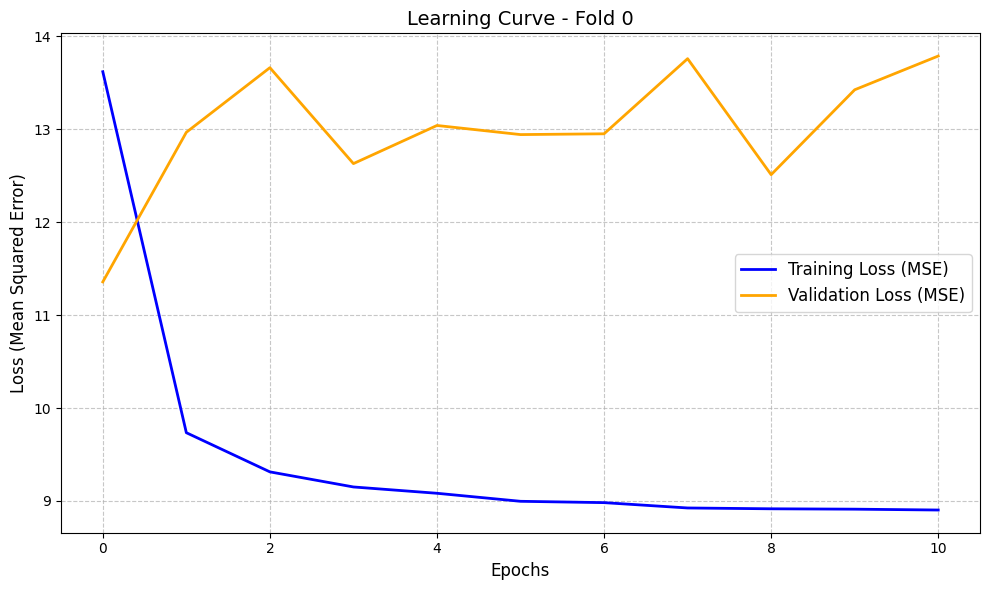

In [12]:

# Extract the list of training histories from the results dictionary
fold_histories = k_fold_dict["histories"]

# Select the specific fold to visualize (e.g., index 0 for the first fold)
target_fold = 0
train_loss = fold_histories[target_fold]['train_loss']
val_loss = fold_histories[target_fold]['val_loss']

# Generate the Learning Curve plot
plt.figure(figsize=(10, 6))

# Plotting Training and Validation metrics
plt.plot(train_loss, label='Training Loss (MSE)', color='blue', linewidth=2)
plt.plot(val_loss, label='Validation Loss (MSE)', color='orange', linewidth=2)

# Chart Formatting
plt.title(f'Learning Curve - Fold {target_fold}', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

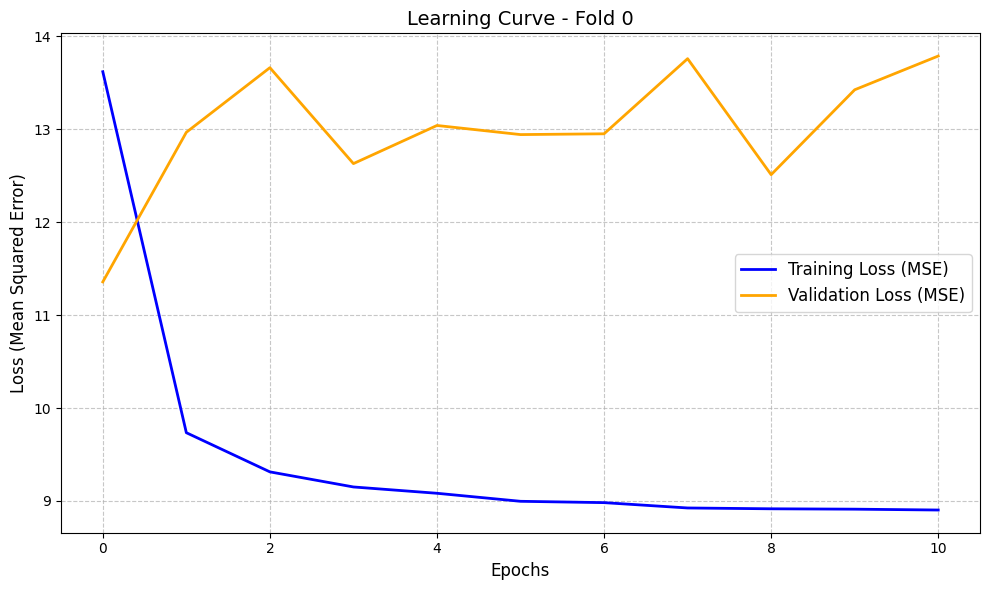

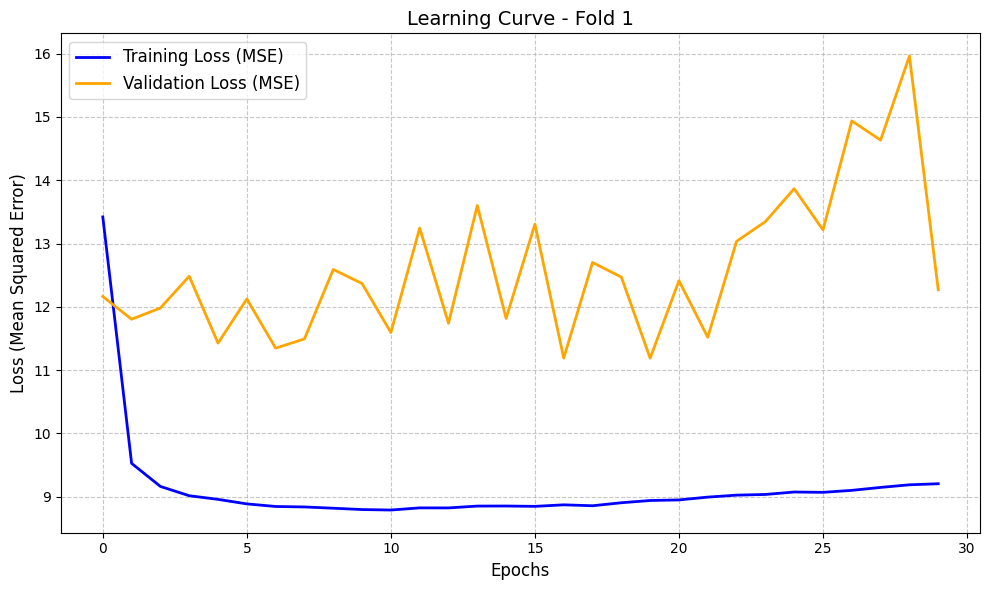

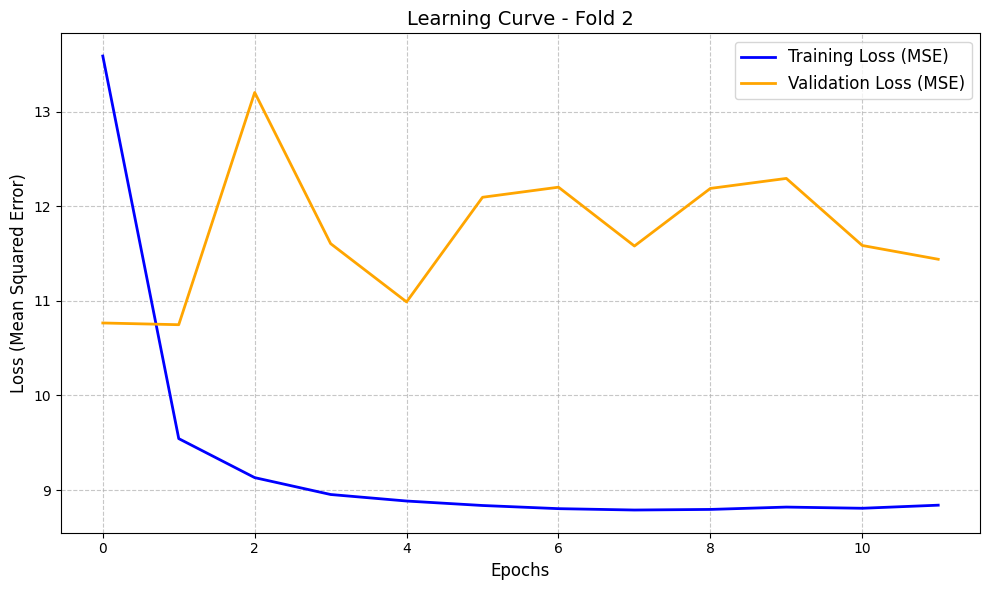

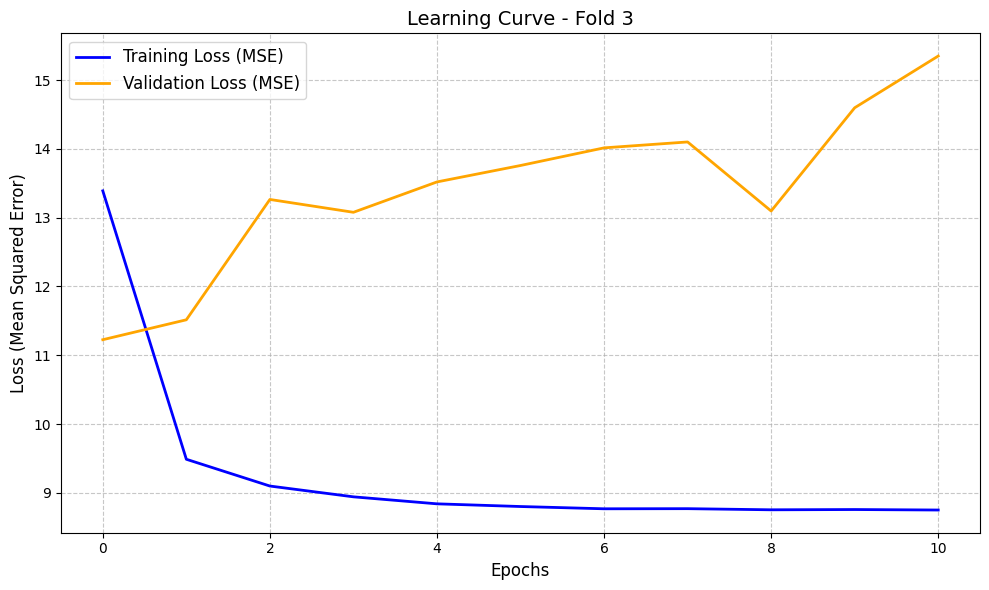

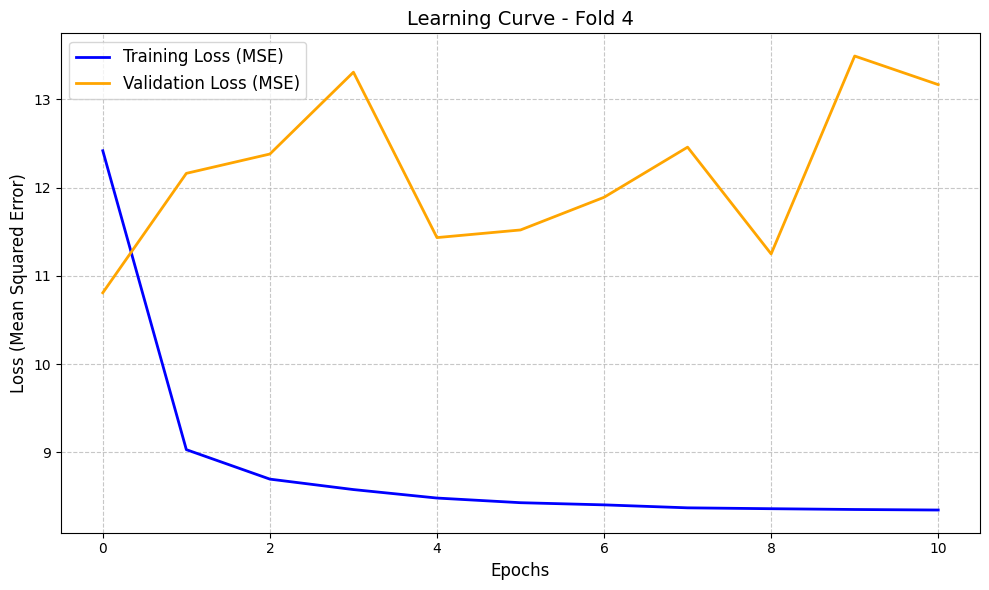

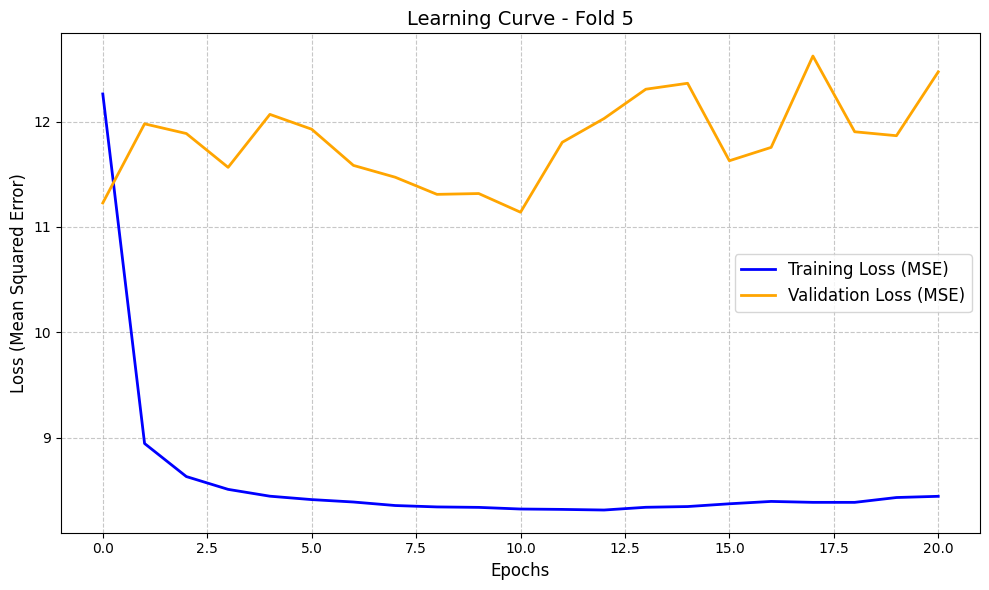

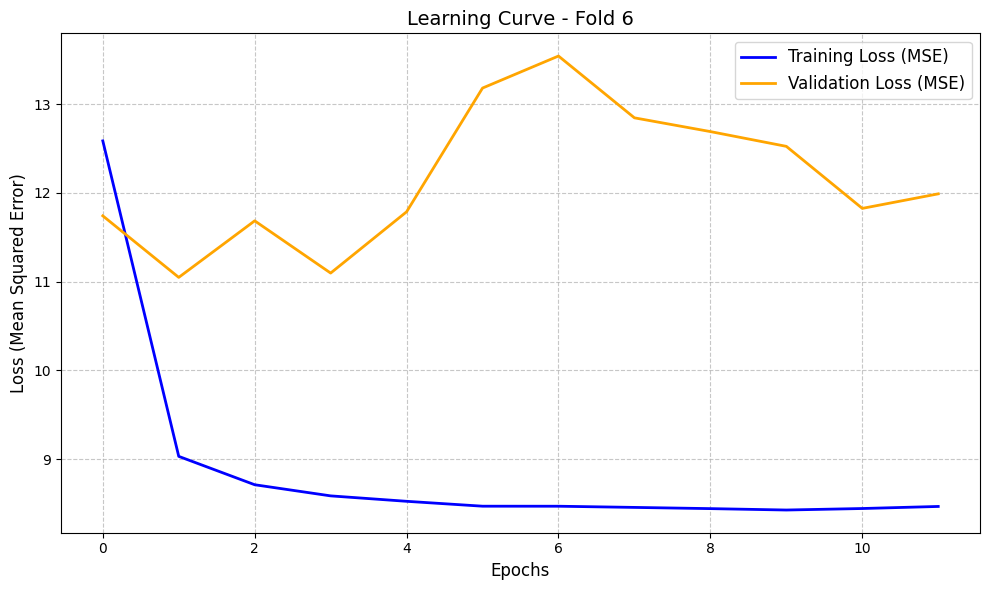

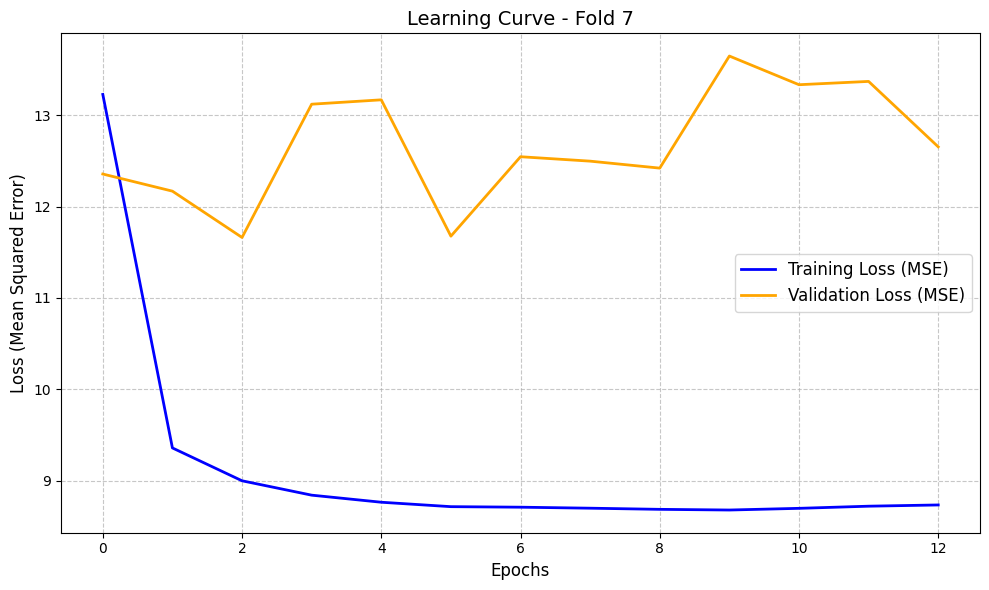

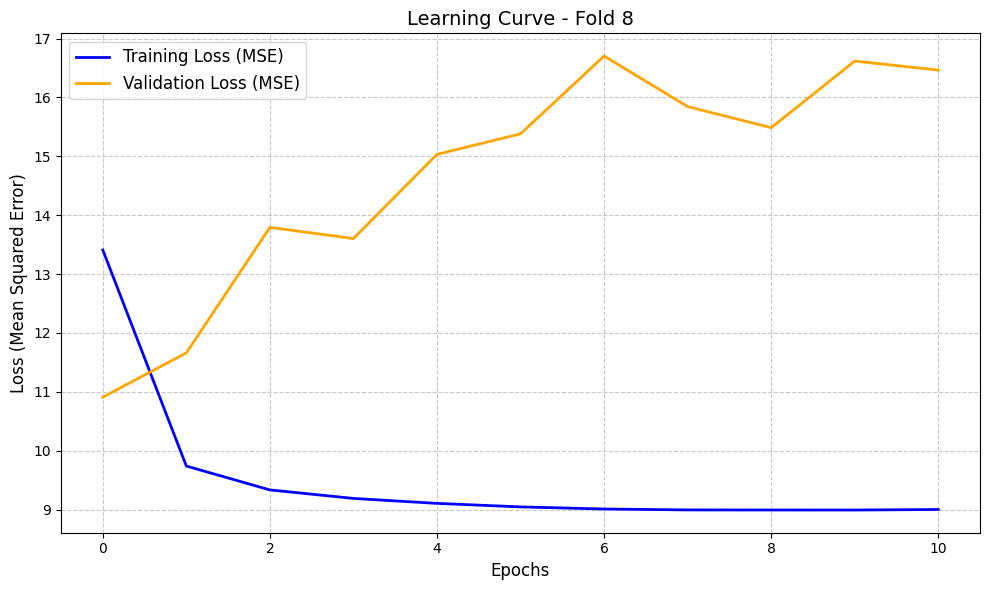

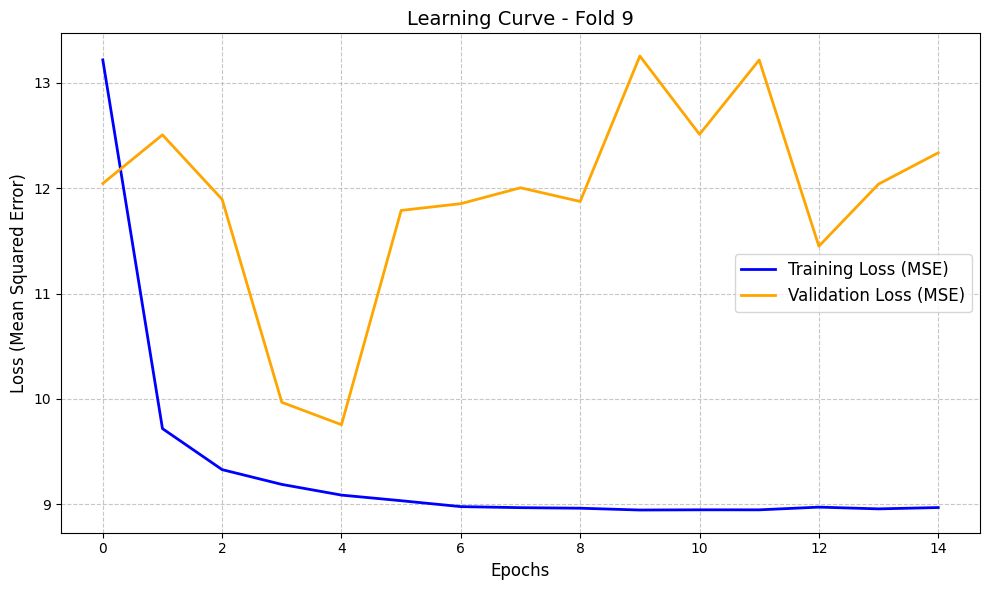

In [13]:
# Extract the list of training histories from the results dictionary
fold_histories = k_fold_dict["histories"]

# Iterate over all available folds
for target_fold, history in enumerate(fold_histories):
    # Extract losses for the current fold
    train_loss = history['train_loss']
    val_loss = history['val_loss']

    # Generate the Learning Curve plot for the current fold
    plt.figure(figsize=(10, 6))

    # Plotting Training and Validation metrics
    plt.plot(train_loss, label='Training Loss (MSE)', color='blue', linewidth=2)
    plt.plot(val_loss, label='Validation Loss (MSE)', color='orange', linewidth=2)

    # Chart Formatting
    plt.title(f'Learning Curve - Fold {target_fold}', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Display the plot
    plt.tight_layout()
    plt.show()

### Saving results

In [14]:
import pickle
from datetime import datetime

timestamp_pick = datetime.now().strftime("%Y%m%d_%H%M%S")

# defining the name of the save file
file_name_pick = f"k_fold_results_exp_1_{timestamp_pick}.pkl"

# opening file in "wb" mode (Write Binary)
with open(file_name_pick, "wb") as f:
    # saving k_fold_dict data in the hard disk
    pickle.dump(k_fold_dict, f)

print(f"Experimental data have been successfully saved in: {file_name_pick}")
print("Saving path:", os.path.abspath(file_name_pick))

Experimental data have been successfully saved in: k_fold_results_exp_1_20260516_113800.pkl
Saving path: /home/emiliano/projects/project_1/Lab_XAI/k_fold_results_exp_1_20260516_113800.pkl


### SHAP